In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import category_encoders as ce


set_config(display='text')


In [2]:
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
df = pd.read_csv('data/train.csv')
print('Dataset shape:', df.shape)

display(df.head())

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

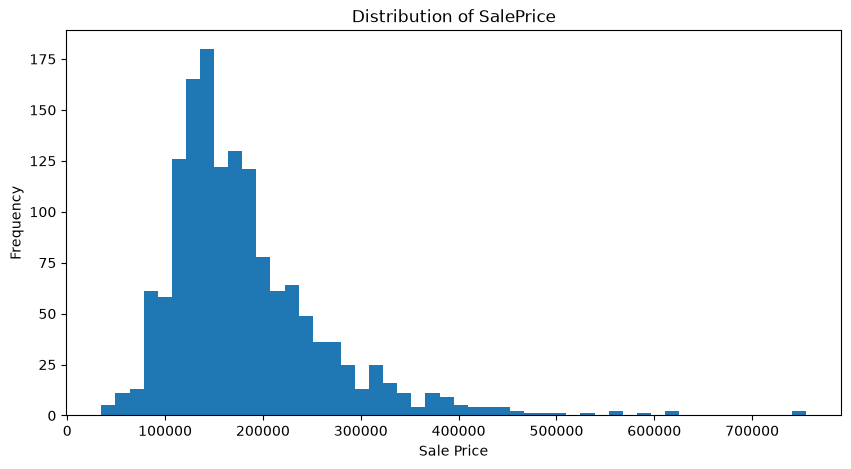

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(df['SalePrice'], bins=50)
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of SalePrice')

plt.show()

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

display(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [8]:
print('Columns with missing values:', len(missing))

Columns with missing values: 19


In [9]:
X = df.drop(columns=['SalePrice', 'Id'])
y = df['SalePrice']

print('X shape', X.shape)
print('y shape', y.shape)

X shape (1460, 79)
y shape (1460,)


In [10]:
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = X.select_dtypes(
    include=['object']
).columns

print('Numerical features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

Numerical features: 36
Categorical features: 43


In [11]:
print('\nNumerical features:')
print(list(numeric_features))

print('\nCategorical features:')
print(list(categorical_features))


Numerical features:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical features:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageTyp

In [12]:
print('Mean:', y.mean())
print('Median:', y.median())
print('Minimum:', y.min())
print('Maximum:', y.max())
print('Skewness:', y.skew())

Mean: 180921.19589041095
Median: 163000.0
Minimum: 34900
Maximum: 755000
Skewness: 1.8828757597682129


In [13]:
y_log = np.log1p(y)

print('Original skewness:', y.skew())
print('Log-transformed skewness:', y_log.skew())

Original skewness: 1.8828757597682129
Log-transformed skewness: 0.12134661989685329


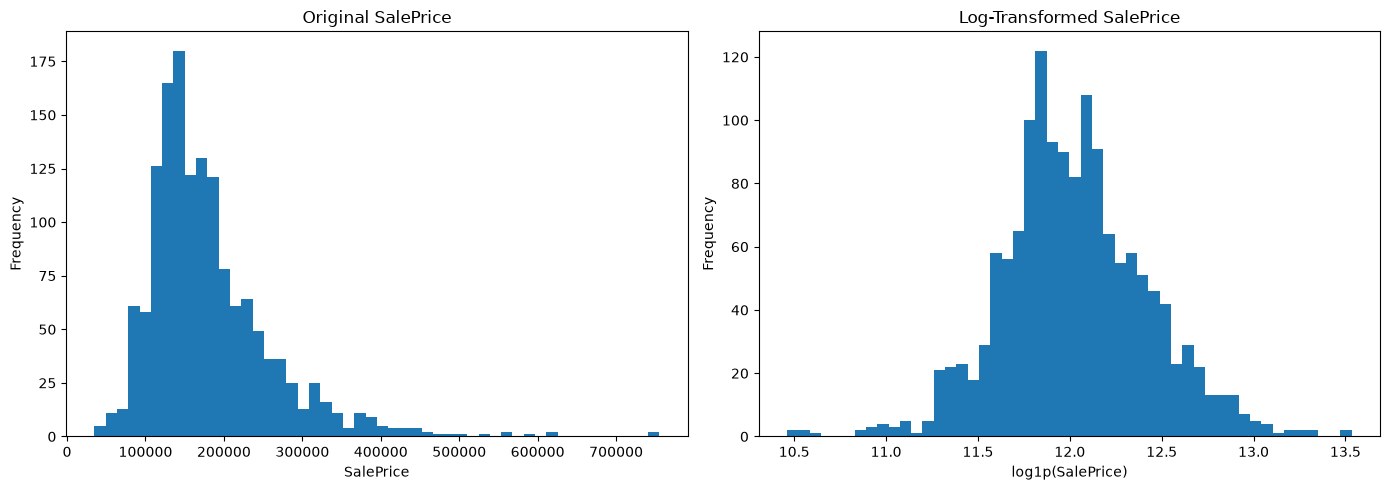

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original target

axes[0].hist(y, bins=50) 
axes[0].set_title('Original SalePrice')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')

# Log-transformed target

axes[1].hist(y_log, bins=50)
axes[1].set_title('Log-Transformed SalePrice')
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_log,
    test_size=0.30,
    random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [16]:
print('Training:', X_train.shape)
print('Validation:', X_valid.shape)
print('TestL', X_test.shape)

Training: (1022, 79)
Validation: (219, 79)
TestL (219, 79)


In [17]:
print('Total samples:', len(X_train) + len(X_valid) + len(X_test))

print('Train percentage:', len(X_train) / len(X) * 100)
print('Validation percentage:', len(X_valid) / len(X) * 100)
print('Test percentage:', len(X_test) / len(X) * 100)

Total samples: 1460
Train percentage: 70.0
Validation percentage: 15.0
Test percentage: 15.0


In [18]:
numeric_missing = X_train[numeric_features].isnull().sum()
numeric_missing = numeric_missing[numeric_missing > 0]

categorical_missing = X_train[categorical_features].isnull().sum()
categorical_missing = categorical_missing[categorical_missing > 0]

print('Numerical columns with missing values:')
display(numeric_missing)

print('\nCategorical columns with missing values:')
display(categorical_missing)

Numerical columns with missing values:


LotFrontage    190
MasVnrArea       3
GarageYrBlt     54
dtype: int64


Categorical columns with missing values:


Alley            956
MasVnrType       590
BsmtQual          26
BsmtCond          26
BsmtExposure      26
BsmtFinType1      26
BsmtFinType2      26
Electrical         1
FireplaceQu      487
GarageType        54
GarageFinish      54
GarageQual        54
GarageCond        54
PoolQC          1017
Fence            820
MiscFeature      982
dtype: int64

In [19]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='Missing'
    )),
    ('target_encoder', ce.TargetEncoder(
        handle_missing='value',
        handle_unknown='value'
    ))
])

preprocessor = ColumnTransformer([
    ('numerical', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

In [20]:
from sklearn.linear_model import ElasticNet

In [21]:
elastic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(
        alpha=0.0005,
        l1_ratio=0.5,
        max_iter=10000,
        random_state=42
    ))
])

In [22]:
elastic_model = elastic_model.fit(X_train, y_train)

In [23]:
valid_pred = elastic_model.predict(X_valid)
print('Validation prediction shape:', valid_pred.shape)

Validation prediction shape: (219,)


In [24]:
rmse = np.sqrt(
    mean_squared_error(y_valid, valid_pred)
)

mae = mean_absolute_error(
    y_valid,
    valid_pred
)

print('Validation RMSE:', rmse)
print('Validation MAE:', mae)

Validation RMSE: 0.1379561862124798
Validation MAE: 0.09463676325932582


In [25]:
valid_pred_price = np.expm1(valid_pred)
valid_actual_price = np.expm1(y_valid)

comparison = pd.DataFrame({
    'Actual Price': valid_actual_price.values,
    'Predicted Price': valid_pred_price
})

display(comparison.head(10))

,Actual Price,Predicted Price
0,147000.0,109032.829440
1,132500.0,128956.997774
2,305000.0,318485.485086
3,335000.0,350757.373865
4,153500.0,158949.434252
5,239000.0,212738.998977
6,200000.0,211834.271931
7,165000.0,180382.536875
8,100000.0,111939.105432
9,277000.0,239322.559552


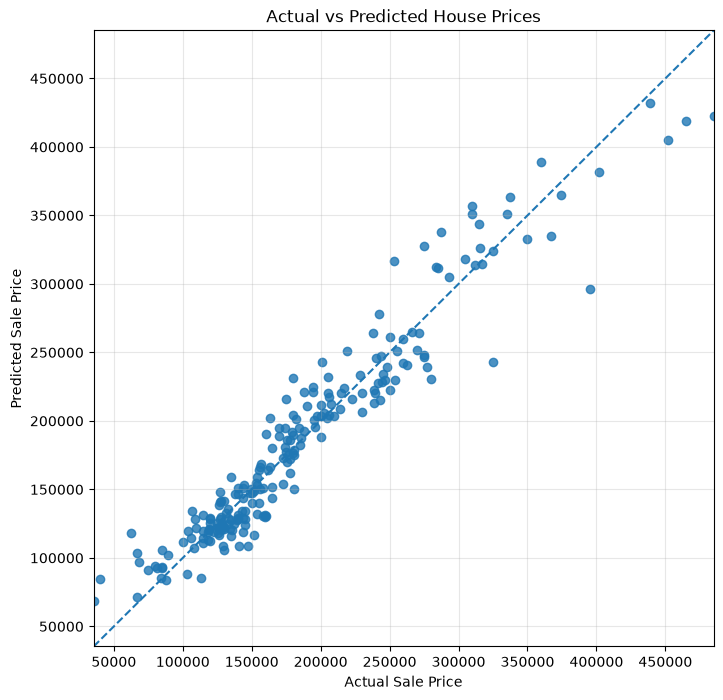

In [26]:
actual = np.asarray(valid_actual_price, dtype=float)
predicted = np.asarray(valid_pred_price, dtype=float)

plt.figure(figsize=(8, 8))

plt.scatter(
    actual,
    predicted,
    alpha=0.8
)

min_price = min(actual.min(), predicted.min())
max_price = max(actual.max(), predicted.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted House Prices')

plt.xlim(min_price, max_price)
plt.ylim(min_price, max_price)

plt.grid(True, alpha=0.3)

plt.show()

In [27]:
rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
mae = mean_absolute_error(y_valid, valid_pred)

print(f'Elastic Validation RMSE: {rmse:.4f}')
print(f'Elastic Validation MAE: {mae:.4f}')


Elastic Validation RMSE: 0.1380
Elastic Validation MAE: 0.0946


In [28]:
rmse_price = np.sqrt(
    mean_squared_error(
        valid_actual_price,
        valid_pred_price
    )
)

mae_price = mean_absolute_error(
    valid_actual_price,
    valid_pred_price
)

print(f'RMSE in dollars: ${rmse_price:,.2f}')
print(f'MAE in dollars: ${mae_price:,.2f}')

RMSE in dollars: $22,038.12
MAE in dollars: $16,091.28


In [32]:
model_results = pd.DataFrame({
    'Model': ['ElasticNet'],
    'Validation RMSE': [rmse],
    'Validation MAE': [mae],
    'RMSE ($)': [rmse_price],
    'MAE ($)': [mae_price]
})

display(model_results)



,Model,Validation RMSE,Validation MAE,RMSE ($),MAE ($)
0,ElasticNet,0.137956,0.094637,22038.122763,16091.278325


In [34]:
from sklearn.ensemble import RandomForestRegressor

In [35]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=500,
        max_features='sqrt',
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

In [36]:
rf_model = rf_model.fit(X_train, y_train_log)

rf_valid_pred = rf_model.predict(X_valid)

print('Random Forest prediction shape:', rf_valid_pred.shape)
print('First 5 predictions:', rf_valid_pred[:5])

NameError: name 'y_train_log' is not defined

In [43]:
rf_rmse = np.sqrt(
    mean_squared_error(y_valid_log, rf_valid_pred)
)

rf_mae = mean_absolute_error(
    y_valid_log, rf_valid_pred
)

print(f'Random Forest RMSE (log): {rf_rmse:.4f}')
print(f'Random Forest MAE (log): {rf_mae:.4f}')

NameError: name 'rf_valid_pred' is not defined

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

In [38]:
gbr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    ))
])

In [39]:
gbr_model = gbr_model.fit(X_train, y_train)

gbr_valid_pred = gbr_model.predict(X_valid)

print('Gradient Boosting prediction shape:', gbr_valid_pred.shape)
print('First 5 predictions:', gbr_valid_pred[:5])

Gradient Boosting prediction shape: (219,)
First 5 predictions: [11.72241071 11.82827754 12.70108969 12.82697019 11.97689876]


In [41]:
gbr_rmse = np.sqrt(
    mean_squared_error(y_valid, gbr_valid_pred)
)

gbr_mae = mean_absolute_error(
    y_valid, gbr_valid_pred
)

print(f'Gradient Boosting RMSE (log): {gbr_rmse:.4f}')
print(f'Gradient Boosting MAE (log): {gbr_mae:.4f}')

Gradient Boosting RMSE (log): 0.1303
Gradient Boosting MAE (log): 0.0837


In [42]:
rf_valid_price = np.expm1(rf_valid_pred)
gbr_valid_price = np.expm1(gbr_valid_pred)

y_valid_price = np.expm1(y_valid)

rf_rmse_price = np.sqrt(
    mean_squared_error(y_valid_price, rf_valid_price)
)

rf_mae_price = mean_absolute_error(
    y_valid_price, rf_valid_price
)

gbr_rmse_price = np.sqrt(
    mean_squared_error(y_valid_price, gbr_valid_price)
)

gbr_mae_price = mean_absolute_error(
    y_valid_price, gbr_valid_price
)


new_results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Validation RMSE': [rf_rmse, gbr_rmse],
    'Validation MAE': [rf_mae, gbr_mae],
    'RMSE ($)': [rf_rmse_price, gbr_rmse_price],
    'MAE ($)': [rf_mae_price, gbr_mae_price]
})

model_results = pd.concat(
    [model_results, new_results],
    ignore_index=True
)

display(model_results)

NameError: name 'rf_valid_pred' is not defined